# GOOGL Stock Movement Prediction
## Part 4: LightGBM Baseline Modeling

This notebook trains the gradient boosting baseline against which the
Temporal Fusion Transformer (Part 5) and iTransformer (Part 6) will be compared.

**Why LightGBM as the baseline:**
- Handles missing values natively (relevant given the sparse fundamental columns from Part 2 — `raw_dda`, `raw_long_term_debt`, etc.)
- Invariant to feature scale and monotonic transforms — no normalization pipeline needed
- Fast to train and tune, giving a reliable reference point before investing compute in the neural architectures
- Gain-based feature importance gives an interpretable view of what drives predictions, useful both for debugging and for the portfolio narrative

**Evaluation philosophy:**
Given the weak feature-target correlations found in Part 3 (max ~0.19),
raw R² is expected to be low. The more meaningful metrics here are:
- **Directional accuracy** — did the model get the sign right?
- **Simulated Sharpe ratio** — would a simple threshold strategy using
  these predictions have been profitable on a risk-adjusted basis?

Both are benchmarked against a **naive baseline** (predict zero return)
to establish whether the model adds any value at all before comparing architectures.

In [15]:
!pip install lightgbm scikit-learn pandas numpy matplotlib seaborn -q

In [16]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

PROCESSED_DIR = "data/processed"
MODEL_DIR     = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(f"{PROCESSED_DIR}/features.csv", index_col=0, parse_dates=True)

with open(f"{PROCESSED_DIR}/split_index.json") as fh:
    split_index = json.load(fh)

with open(f"{PROCESSED_DIR}/selected_features.json") as fh:
    selected_features = json.load(fh)

TREE_FEATURES = selected_features["tree_model_features"]
TARGET_COLS   = selected_features["target_columns"]
HORIZONS      = {"target_return_1d": "1d", "target_return_5d": "5d", "target_return_20d": "20d"}

print(f"Full dataset shape : {df.shape}")
print(f"Tree model features: {len(TREE_FEATURES)}")
print(f"Targets            : {TARGET_COLS}")

Full dataset shape : (3134, 157)
Tree model features: 111
Targets            : ['target_return_1d', 'target_return_5d', 'target_return_20d']


In [17]:
train_mask = (df.index >= split_index["train_start"]) & (df.index <= split_index["train_end"])
val_mask   = (df.index >= split_index["val_start"])   & (df.index <= split_index["val_end"])
test_mask  = (df.index >= split_index["test_start"])  & (df.index <= split_index["test_end"])

X_train, X_val, X_test = df.loc[train_mask, TREE_FEATURES], df.loc[val_mask, TREE_FEATURES], df.loc[test_mask, TREE_FEATURES]

print(f"Train : {X_train.shape}  ({df.index[train_mask].min().date()} to {df.index[train_mask].max().date()})")
print(f"Val   : {X_val.shape}  ({df.index[val_mask].min().date()} to {df.index[val_mask].max().date()})")
print(f"Test  : {X_test.shape}  ({df.index[test_mask].min().date()} to {df.index[test_mask].max().date()})")

Train : (2015, 111)  (2014-01-02 to 2021-12-31)
Val   : (501, 111)  (2022-01-03 to 2023-12-29)
Test  : (618, 111)  (2024-01-02 to 2026-06-18)


## Train One LightGBM Model Per Horizon

Each horizon is trained independently since the optimal tree depth, regularization, and number of boosting rounds differ meaningfully between
a noisy 1-day target and a smoother 20-day target. Early stopping on the validation set determines the number of boosting rounds per model, which also acts as the primary regularization mechanism here.

Hyperparameters are set conservatively given the dataset size (~2000
training rows, 111 features) — shallow trees and a high minimum samples
per leaf to limit overfitting capacity

In [18]:
LGBM_PARAMS = {
    "objective"        : "regression",
    "metric"           : "mae",
    "boosting_type"    : "gbdt",
    "num_leaves"       : 15,
    "max_depth"        : 4,
    "learning_rate"    : 0.02,
    "min_child_samples": 30,
    "subsample"        : 0.8,
    "subsample_freq"   : 1,
    "colsample_bytree" : 0.7,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.5,
    "verbosity"        : -1,
    "seed"             : 42,
}

N_BOOST_ROUNDS  = 2000
EARLY_STOPPING  = 100


def train_lgbm_for_horizon(target_col: str):
    y_train = df.loc[train_mask, target_col]
    y_val   = df.loc[val_mask, target_col]

    # Drop rows with NaN target (final n rows of each split, no future price)
    train_valid = y_train.notna()
    val_valid   = y_val.notna()

    train_set = lgb.Dataset(X_train[train_valid], label=y_train[train_valid])
    val_set   = lgb.Dataset(X_val[val_valid], label=y_val[val_valid], reference=train_set)

    model = lgb.train(
        LGBM_PARAMS,
        train_set,
        num_boost_round=N_BOOST_ROUNDS,
        valid_sets=[train_set, val_set],
        valid_names=["train", "val"],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )

    return model


models = {}
for target_col in TARGET_COLS:
    horizon = HORIZONS[target_col]
    print(f"Training LightGBM for {horizon}...")
    model = train_lgbm_for_horizon(target_col)
    models[target_col] = model
    print(f"  Best iteration: {model.best_iteration}")
    print(f"  Best val MAE  : {model.best_score['val']['l1']:.6f}")
    print()

Training LightGBM for 1d...
  Best iteration: 24
  Best val MAE  : 0.016341

Training LightGBM for 5d...
  Best iteration: 19
  Best val MAE  : 0.036699

Training LightGBM for 20d...
  Best iteration: 20
  Best val MAE  : 0.063754



In [19]:
for target_col, model in models.items():
    horizon = HORIZONS[target_col]
    model.save_model(f"{MODEL_DIR}/lgbm_{horizon}.txt")

print(f"Models saved to {MODEL_DIR}/")

Models saved to models/


## Generate Predictions

In [20]:
predictions = pd.DataFrame(index=df.index[val_mask | test_mask])

for target_col, model in models.items():
    horizon = HORIZONS[target_col]
    X_combined = pd.concat([X_val, X_test])
    predictions[f"pred_{horizon}"] = model.predict(X_combined, num_iteration=model.best_iteration)
    predictions[f"actual_{horizon}"] = df.loc[predictions.index, target_col]

predictions["split"] = np.where(predictions.index.isin(df.index[val_mask]), "val", "test")

predictions.to_csv(f"{PROCESSED_DIR}/lgbm_predictions.csv")
print(f"Predictions shape: {predictions.shape}")
print(predictions.head())

Predictions shape: (1119, 7)
             pred_1d  actual_1d   pred_5d  actual_5d  pred_20d  actual_20d  \
date                                                                         
2022-01-03  0.000931  -0.004083  0.000372  -0.043603  0.001392   -0.050676   
2022-01-04  0.000931  -0.045876  0.000345  -0.032296  0.001392    0.024934   
2022-01-05  0.000903  -0.000199  0.002692   0.026532  0.003247    0.038577   
2022-01-06  0.000706  -0.005303  0.002692   0.006094  0.003102    0.040258   
2022-01-07  0.000777   0.012061  0.002692   0.017980  0.003102    0.015940   

           split  
date              
2022-01-03   val  
2022-01-04   val  
2022-01-05   val  
2022-01-06   val  
2022-01-07   val  


## Regression Metrics

In [21]:
def compute_regression_metrics(actual: pd.Series, predicted: pd.Series) -> dict:
    valid = actual.notna() & predicted.notna()
    actual, predicted = actual[valid], predicted[valid]
    return {
        "mae" : mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "r2"  : r2_score(actual, predicted),
        "n"   : int(valid.sum()),
    }

regression_results = {}
for horizon in ["1d", "5d", "20d"]:
    regression_results[horizon] = {}
    for split_name in ["val", "test"]:
        mask = predictions["split"] == split_name
        metrics = compute_regression_metrics(
            predictions.loc[mask, f"actual_{horizon}"],
            predictions.loc[mask, f"pred_{horizon}"],
        )
        regression_results[horizon][split_name] = metrics

print("Regression metrics (MAE, RMSE, R2):")
for horizon, splits in regression_results.items():
    print(f"\n  {horizon}:")
    for split_name, m in splits.items():
        print(f"    {split_name:<5} | MAE={m['mae']:.5f}  RMSE={m['rmse']:.5f}  R2={m['r2']:+.4f}  n={m['n']}")

Regression metrics (MAE, RMSE, R2):

  1d:
    val   | MAE=0.01634  RMSE=0.02192  R2=+0.0016  n=501
    test  | MAE=0.01384  RMSE=0.01918  R2=-0.0108  n=617

  5d:
    val   | MAE=0.03670  RMSE=0.04675  R2=+0.0092  n=501
    test  | MAE=0.03368  RMSE=0.04325  R2=-0.0415  n=613

  20d:
    val   | MAE=0.06375  RMSE=0.08080  R2=-0.0150  n=501
    test  | MAE=0.07445  RMSE=0.09325  R2=-0.0853  n=598


## Naive Baseline Comparison

The naive baseline predicts zero return for every observation — the
simplest possible forecast and a standard benchmark for return prediction.
If the model's MAE is not meaningfully better than predicting zero, it has
not learned a useful signal, regardless of how the R2 looks in isolation.

In [22]:
naive_results = {}
for horizon in ["1d", "5d", "20d"]:
    naive_results[horizon] = {}
    for split_name in ["val", "test"]:
        mask = predictions["split"] == split_name
        actual = predictions.loc[mask, f"actual_{horizon}"]
        naive_pred = pd.Series(0.0, index=actual.index)
        naive_results[horizon][split_name] = compute_regression_metrics(actual, naive_pred)

print("Naive baseline (predict zero) MAE comparison:")
print(f"{'Horizon':<8}{'Split':<6}{'Model MAE':<12}{'Naive MAE':<12}{'Improvement':<12}")
for horizon in ["1d", "5d", "20d"]:
    for split_name in ["val", "test"]:
        model_mae = regression_results[horizon][split_name]["mae"]
        naive_mae = naive_results[horizon][split_name]["mae"]
        improvement = (naive_mae - model_mae) / naive_mae * 100
        print(f"{horizon:<8}{split_name:<6}{model_mae:<12.5f}{naive_mae:<12.5f}{improvement:>+10.2f}%")

Naive baseline (predict zero) MAE comparison:
Horizon Split Model MAE   Naive MAE   Improvement 
1d      val   0.01634     0.01635          +0.07%
1d      test  0.01384     0.01383          -0.11%
5d      val   0.03670     0.03680          +0.27%
5d      test  0.03368     0.03377          +0.26%
20d     val   0.06375     0.06422          +0.72%
20d     test  0.07445     0.07790          +4.43%


## Directional Accuracy

Measures whether the model correctly predicts the sign of the return, independent of magnitude. A naive baseline here is the historical base
rate of positive days (52.9% / 56.4% / 60.5% for 1d/5d/20d, established in Part 3) — a model needs to beat this, not just beat 50%, to add value.

In [23]:
directional_results = {}
for horizon in ["1d", "5d", "20d"]:
    directional_results[horizon] = {}
    for split_name in ["val", "test"]:
        mask = predictions["split"] == split_name
        actual = predictions.loc[mask, f"actual_{horizon}"]
        pred   = predictions.loc[mask, f"pred_{horizon}"]
        valid  = actual.notna() & pred.notna()

        correct_direction = (np.sign(actual[valid]) == np.sign(pred[valid]))
        base_rate = (actual[valid] > 0).mean()

        directional_results[horizon][split_name] = {
            "accuracy" : float(correct_direction.mean()),
            "base_rate": float(base_rate),
            "n"        : int(valid.sum()),
        }

print("Directional accuracy vs base rate (% positive days):")
print(f"{'Horizon':<8}{'Split':<6}{'Accuracy':<12}{'Base Rate':<12}{'Edge':<10}")
for horizon in ["1d", "5d", "20d"]:
    for split_name in ["val", "test"]:
        r = directional_results[horizon][split_name]
        edge = r["accuracy"] - max(r["base_rate"], 1 - r["base_rate"])
        print(f"{horizon:<8}{split_name:<6}{r['accuracy']:<12.4f}{r['base_rate']:<12.4f}{edge:>+8.4f}")

Directional accuracy vs base rate (% positive days):
Horizon Split Accuracy    Base Rate   Edge      
1d      val   0.4990      0.4950       -0.0060
1d      test  0.4700      0.5527       -0.0827
5d      val   0.5409      0.5030       +0.0379
5d      test  0.4943      0.5889       -0.0946
20d     val   0.5429      0.5429       +0.0000
20d     test  0.6455      0.6488       -0.0033


## Simulated Trading Strategy and Sharpe Ratio

A simple long/flat strategy: go long when the predicted return exceeds a threshold, stay in cash otherwise. This is deliberately simple (no shorting, no position sizing) to isolate whether the prediction signal itself carries economic value before adding strategy complexity.

Transaction costs are approximated at 5 basis points per round-trip trade, a reasonable estimate for a liquid large-cap stock.

In [24]:
TRANSACTION_COST_BPS = 5
TRADING_DAYS_PER_YEAR = 252

HORIZON_DAYS = {"1d": 1, "5d": 5, "20d": 20}


def simulate_strategy(actual_returns: pd.Series, predicted_returns: pd.Series,
                      horizon_days: int, threshold: float = 0.0) -> dict:
    """
    Simulates a long/flat strategy with rebalancing only every `horizon_days`
    trading days, avoiding the overlapping-window compounding error that
    occurs if every row's N-day forward return is treated as an independent
    realized return.
    """
    valid = actual_returns.notna() & predicted_returns.notna()
    actual, predicted = actual_returns[valid], predicted_returns[valid]

    # Take every horizon_days-th observation so consecutive blocks do not overlap
    block_idx = actual.index[::horizon_days]
    actual_block    = actual.loc[block_idx]
    predicted_block = predicted.loc[block_idx]

    position = (predicted_block > threshold).astype(int)
    position_change = position.diff().abs().fillna(position.iloc[0] if len(position) > 0 else 0)

    strategy_returns = position * actual_block
    transaction_costs = position_change * (TRANSACTION_COST_BPS / 10000)
    net_returns = strategy_returns - transaction_costs

    buy_hold_returns = actual_block

    periods_per_year = TRADING_DAYS_PER_YEAR / horizon_days

    sharpe    = (net_returns.mean() / net_returns.std() * np.sqrt(periods_per_year)
                 if net_returns.std() > 0 else 0.0)
    bh_sharpe = (buy_hold_returns.mean() / buy_hold_returns.std() * np.sqrt(periods_per_year)
                 if buy_hold_returns.std() > 0 else 0.0)

    cumulative_strategy = (1 + net_returns).cumprod()
    cumulative_buyhold  = (1 + buy_hold_returns).cumprod()

    return {
        "sharpe_ratio"        : float(sharpe),
        "buy_hold_sharpe"     : float(bh_sharpe),
        "total_return"        : float(cumulative_strategy.iloc[-1] - 1) if len(cumulative_strategy) > 0 else 0.0,
        "buy_hold_return"     : float(cumulative_buyhold.iloc[-1] - 1) if len(cumulative_buyhold) > 0 else 0.0,
        "n_trades"            : int(position_change.sum()),
        "n_periods"           : int(len(net_returns)),
        "pct_time_long"       : float(position.mean()) if len(position) > 0 else 0.0,
        "cumulative_strategy" : cumulative_strategy,
        "cumulative_buyhold"  : cumulative_buyhold,
    }


strategy_results = {}
for horizon in ["1d", "5d", "20d"]:
    strategy_results[horizon] = {}
    for split_name in ["val", "test"]:
        mask = predictions["split"] == split_name
        result = simulate_strategy(
            predictions.loc[mask, f"actual_{horizon}"],
            predictions.loc[mask, f"pred_{horizon}"],
            horizon_days=HORIZON_DAYS[horizon],
        )
        strategy_results[horizon][split_name] = result

print("Simulated long/flat strategy (threshold=0, non-overlapping rebalance):")
print(f"{'Horizon':<8}{'Split':<6}{'Sharpe':<10}{'B&H Sharpe':<12}{'Tot Return':<12}{'B&H Return':<12}{'Trades':<8}{'Periods':<8}")
for horizon in ["1d", "5d", "20d"]:
    for split_name in ["val", "test"]:
        r = strategy_results[horizon][split_name]
        print(f"{horizon:<8}{split_name:<6}{r['sharpe_ratio']:<10.3f}{r['buy_hold_sharpe']:<12.3f}"
              f"{r['total_return']:<+12.3f}{r['buy_hold_return']:<+12.3f}{r['n_trades']:<8}{r['n_periods']:<8}")

Simulated long/flat strategy (threshold=0, non-overlapping rebalance):
Horizon Split Sharpe    B&H Sharpe  Tot Return  B&H Return  Trades  Periods 
1d      val   -0.068    0.105       -0.104      -0.047      70      501     
1d      test  0.286     1.483       +0.079      +1.687      100     617     
5d      val   0.513     0.092       +0.235      -0.042      24      101     
5d      test  0.843     1.532       +0.549      +1.725      41      123     
20d     val   0.249     0.211       +0.067      +0.045      3       26      
20d     test  1.613     1.526       +1.520      +1.838      3       30      


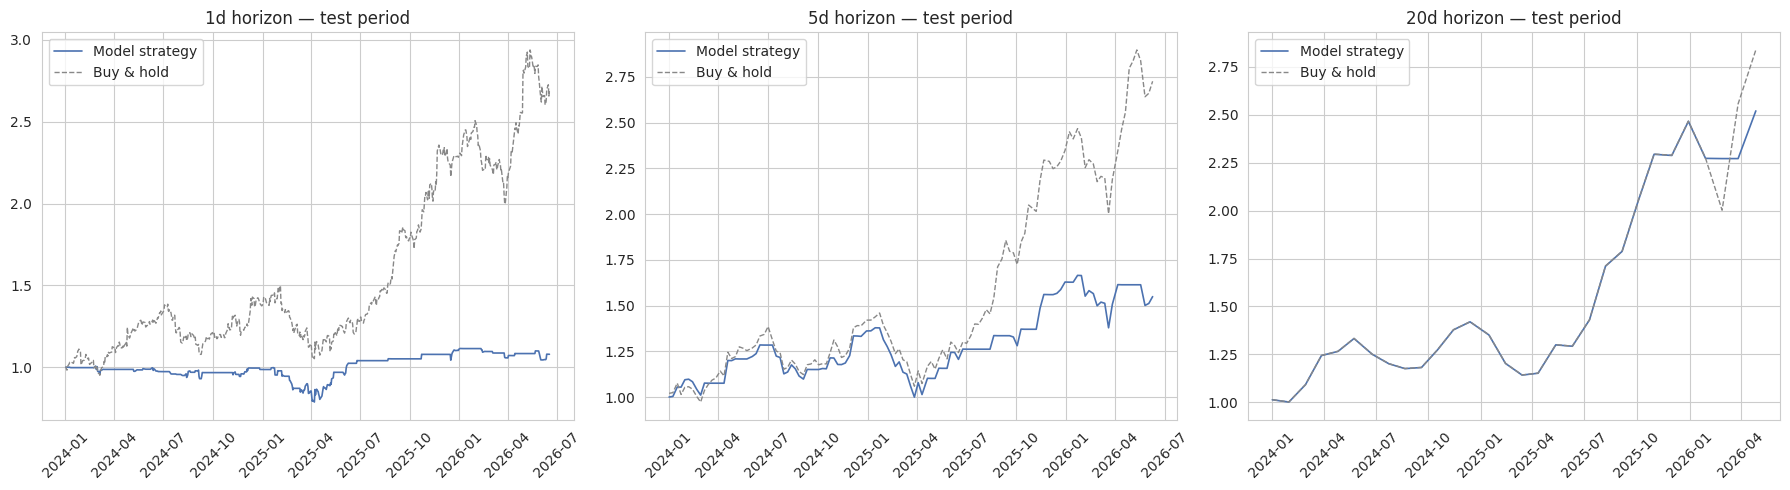

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, horizon in zip(axes, ["1d", "5d", "20d"]):
    test_result = strategy_results[horizon]["test"]
    ax.plot(test_result["cumulative_strategy"].index, test_result["cumulative_strategy"],
            label="Model strategy", color="#4C72B0", linewidth=1.2)
    ax.plot(test_result["cumulative_buyhold"].index, test_result["cumulative_buyhold"],
            label="Buy & hold", color="#888888", linewidth=1.0, linestyle="--")
    ax.set_title(f"{horizon} horizon — test period")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("lgbm_strategy_performance.png", dpi=120, bbox_inches="tight")
plt.show()

## Feature Importance

In [26]:
importance_frames = []
for target_col, model in models.items():
    horizon = HORIZONS[target_col]
    importance = pd.DataFrame({
        "feature": model.feature_name(),
        "gain"   : model.feature_importance(importance_type="gain"),
        "split"  : model.feature_importance(importance_type="split"),
    })
    importance["horizon"] = horizon
    importance["gain_pct"] = importance["gain"] / importance["gain"].sum() * 100
    importance_frames.append(importance.sort_values("gain", ascending=False))

importance_df = pd.concat(importance_frames, ignore_index=True)
importance_df.to_csv(f"{PROCESSED_DIR}/lgbm_feature_importance.csv", index=False)

for horizon in ["1d", "5d", "20d"]:
    print(f"\nTop 15 features by gain — {horizon}:")
    top = importance_df[importance_df["horizon"] == horizon].head(15)
    print(top[["feature", "gain_pct"]].to_string(index=False))


Top 15 features by gain — 1d:
              feature  gain_pct
         obv_momentum 12.446893
                  vix 10.987221
          vix_20d_chg 10.741076
       log_return_60d  8.567168
           vix_5d_chg  4.406781
               adx_14  3.650346
             pb_ratio  3.617599
             bb_width  2.612872
             ps_ratio  2.425409
        real_rate_10y  2.366255
              stoch_d  2.136694
     volume_zscore_20  2.082093
    volume_ratio_5_20  1.972130
oil_price_wti_20d_chg  1.953762
               rsi_14  1.853135

Top 15 features by gain — 5d:
              feature  gain_pct
              stoch_d  7.547371
             pb_ratio  7.291129
               adx_14  7.106920
             ps_ratio  6.841374
          treasury_2y  6.661568
               atr_14  3.598882
price_corr_nasdaq_60d  3.499701
 receivables_turnover  3.283371
                  vix  3.072821
       net_income_qoq  2.894182
             pe_ratio  2.524188
       log_return_60d  2.274351
oil_price_

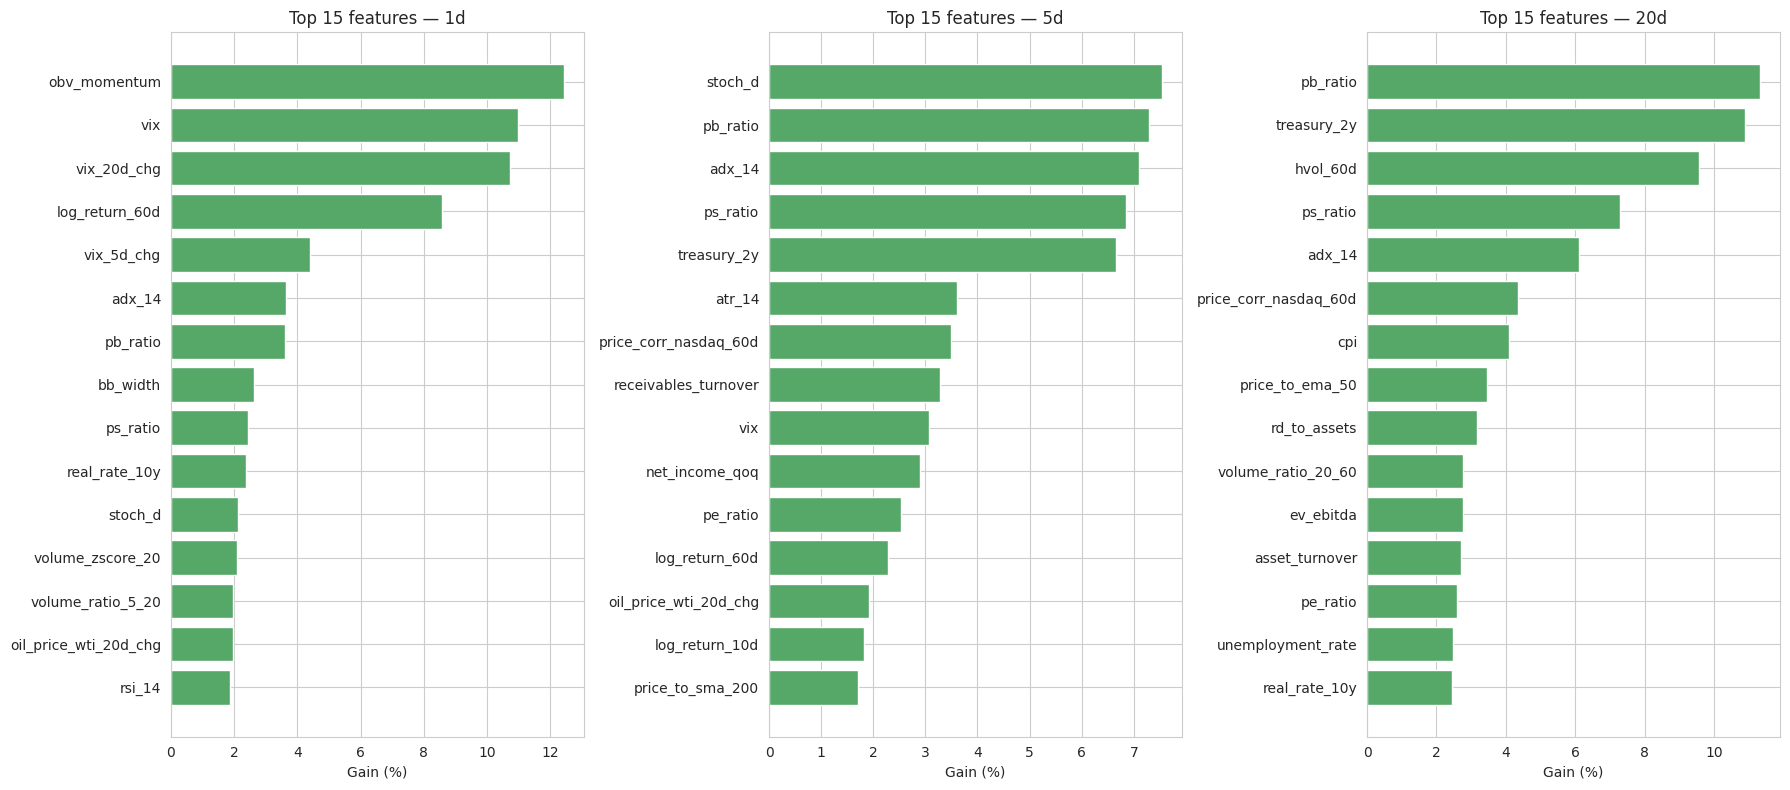

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, horizon in zip(axes, ["1d", "5d", "20d"]):
    top = importance_df[importance_df["horizon"] == horizon].nlargest(15, "gain")
    ax.barh(top["feature"][::-1], top["gain_pct"][::-1], color="#55A868")
    ax.set_title(f"Top 15 features — {horizon}")
    ax.set_xlabel("Gain (%)")

plt.tight_layout()
plt.savefig("lgbm_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## Save Final Metrics Summary

In [29]:
final_metrics = {
    "regression"  : regression_results,
    "naive_baseline": naive_results,
    "directional" : directional_results,
    "strategy"    : {
        horizon: {
            split_name: {k: v for k, v in result.items() if not isinstance(v, pd.Series)}
            for split_name, result in splits.items()
        }
        for horizon, splits in strategy_results.items()
    },
    "best_iterations": {HORIZONS[t]: int(m.best_iteration) for t, m in models.items()},
}

with open(f"{PROCESSED_DIR}/lgbm_metrics.json", "w") as fh:
    json.dump(final_metrics, fh, indent=2)

print("  PART 4 SUMMARY — LIGHTGBM BASELINE")
for horizon in ["1d", "5d", "20d"]:
    test_reg  = regression_results[horizon]["test"]
    test_dir  = directional_results[horizon]["test"]
    test_strat = strategy_results[horizon]["test"]
    print(f"\n  {horizon} horizon (test set):")
    print(f"    MAE                : {test_reg['mae']:.5f}")
    print(f"    Directional acc    : {test_dir['accuracy']:.4f}  (base rate: {test_dir['base_rate']:.4f})")
    print(f"    Strategy Sharpe    : {test_strat['sharpe_ratio']:.3f}  (buy-hold: {test_strat['buy_hold_sharpe']:.3f})")
    print(f"    Strategy return    : {test_strat['total_return']:+.3f}  (buy-hold: {test_strat['buy_hold_return']:+.3f})")

print(f"\n  Models saved to        : {MODEL_DIR}/")
print(f"  Predictions saved to   : {PROCESSED_DIR}/lgbm_predictions.csv")
print(f"  Feature importance to  : {PROCESSED_DIR}/lgbm_feature_importance.csv")
print(f"  Full metrics saved to  : {PROCESSED_DIR}/lgbm_metrics.json")
print("\n  Ready for Part 5: Temporal Fusion Transformer")

  PART 4 SUMMARY — LIGHTGBM BASELINE

  1d horizon (test set):
    MAE                : 0.01384
    Directional acc    : 0.4700  (base rate: 0.5527)
    Strategy Sharpe    : 0.286  (buy-hold: 1.483)
    Strategy return    : +0.079  (buy-hold: +1.687)

  5d horizon (test set):
    MAE                : 0.03368
    Directional acc    : 0.4943  (base rate: 0.5889)
    Strategy Sharpe    : 0.843  (buy-hold: 1.532)
    Strategy return    : +0.549  (buy-hold: +1.725)

  20d horizon (test set):
    MAE                : 0.07445
    Directional acc    : 0.6455  (base rate: 0.6488)
    Strategy Sharpe    : 1.613  (buy-hold: 1.526)
    Strategy return    : +1.520  (buy-hold: +1.838)

  Models saved to        : models/
  Predictions saved to   : data/processed/lgbm_predictions.csv
  Feature importance to  : data/processed/lgbm_feature_importance.csv
  Full metrics saved to  : data/processed/lgbm_metrics.json

  Ready for Part 5: Temporal Fusion Transformer
